<a href="https://colab.research.google.com/github/ekoshkaa/is_4487_base/blob/main/Assignments/assignment_04_data_understanding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IS4487 Week 4 - Assignment

### Outline

Our Goals with this Project:

1. Import and review the data
2. Perform EDA and Clean Data

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_04_data_understanding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# ---------- Assumptions from your essay ----------

stages = ["Initial Review", "Email Comm (Bottleneck)", "KYC / Compliance", "Account Setup"]

# Activity times and capacities (cases/day)
activity_time_min = [20, 30, 25, 15]
capacity_cases = [24, 16, 19, 32]   # 480 minutes / time per case

# Process flow rate is limited by the bottleneck (email)
flow_rate = 16           # cases per day
demand_cases = 60        # incoming cases per day (peak)

# Utilization per stage
utilization = [flow_rate / c for c in capacity_cases]   # fractions, 0–1


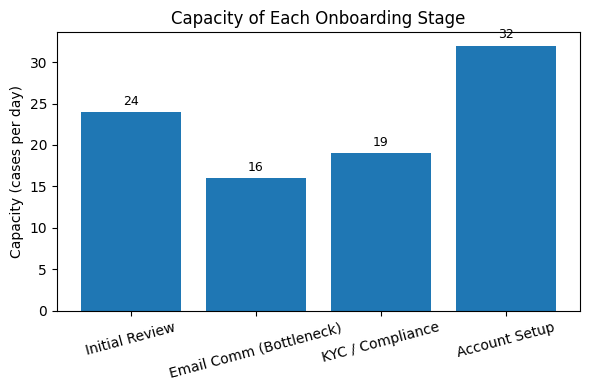

In [2]:
plt.figure(figsize=(6, 4))
x = np.arange(len(stages))

plt.bar(x, capacity_cases)
plt.xticks(x, stages, rotation=15)
plt.ylabel("Capacity (cases per day)")
plt.title("Capacity of Each Onboarding Stage")

# optional labels on top of bars
for i, c in enumerate(capacity_cases):
    plt.text(i, c + 0.5, str(c), ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("gs_capacity_per_stage.png", dpi=300, bbox_inches="tight")
plt.show()


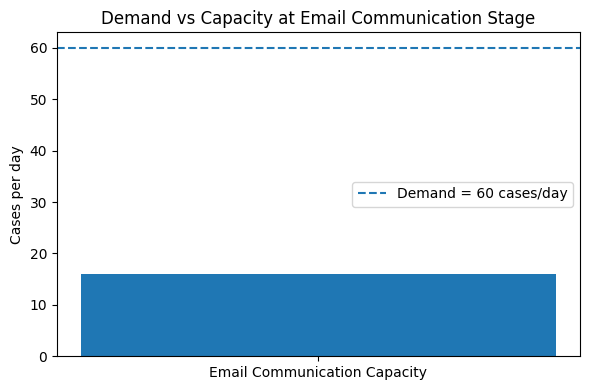

In [3]:
plt.figure(figsize=(6, 4))

plt.bar(["Email Communication Capacity"], [capacity_cases[1]])
plt.axhline(demand_cases, linestyle="--", label=f"Demand = {demand_cases} cases/day")

plt.ylabel("Cases per day")
plt.title("Demand vs Capacity at Email Communication Stage")
plt.legend()

plt.tight_layout()
plt.savefig("gs_demand_vs_capacity_email.png", dpi=300, bbox_inches="tight")
plt.show()


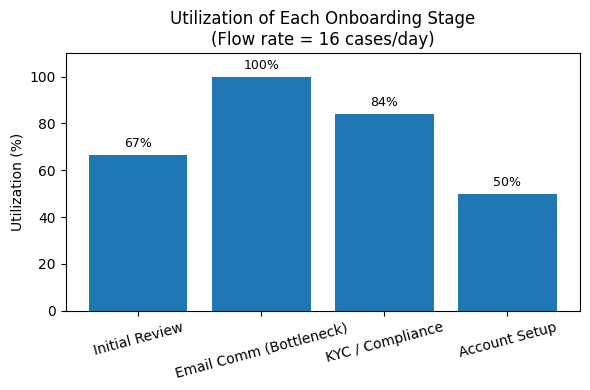

In [4]:
plt.figure(figsize=(6, 4))
x = np.arange(len(stages))

plt.bar(x, [u * 100 for u in utilization])
plt.xticks(x, stages, rotation=15)
plt.ylabel("Utilization (%)")
plt.title("Utilization of Each Onboarding Stage\n(Flow rate = 16 cases/day)")
plt.ylim(0, 110)

for i, u in enumerate(utilization):
    plt.text(i, u * 100 + 2, f"{u*100:.0f}%", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("gs_utilization_per_stage.png", dpi=300, bbox_inches="tight")
plt.show()


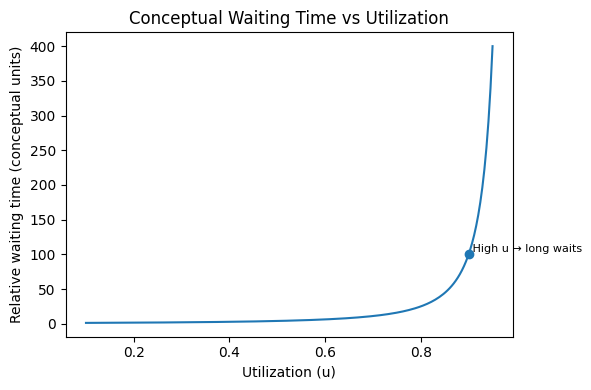

In [5]:
u_vals = np.linspace(0.1, 0.95, 200)
waiting_time = 1 / (1 - u_vals) ** 2   # conceptual shape

plt.figure(figsize=(6, 4))
plt.plot(u_vals, waiting_time)

plt.xlabel("Utilization (u)")
plt.ylabel("Relative waiting time (conceptual units)")
plt.title("Conceptual Waiting Time vs Utilization")

# mark a high-utilization point (like the bottleneck)
u_mark = 0.9
wt_mark = 1 / (1 - u_mark) ** 2
plt.scatter([u_mark], [wt_mark])
plt.text(u_mark, wt_mark, " High u → long waits", ha="left", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig("waiting_time_vs_utilization.png", dpi=300, bbox_inches="tight")
plt.show()


In [6]:
import pandas as pd

data = {
    "Stage": stages,
    "Activity time (min/case)": activity_time_min,
    "Capacity (cases/day)": capacity_cases,
    "Utilization (%)": [round(u * 100, 1) for u in utilization]
}

df = pd.DataFrame(data)
df


,Stage,Activity time (min/case),Capacity (cases/day),Utilization (%)
0,Initial Review,20,24,66.7
1,Email Comm (Bottleneck),30,16,100.0
2,KYC / Compliance,25,19,84.2
3,Account Setup,15,32,50.0


In [7]:
!jupyter nbconvert --to html "OSC3050project_Yerke.ipynb"

[NbConvertApp] Converting notebook OSC3050project_Yerke.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 4 image(s).
[NbConvertApp] Writing 455085 bytes to OSC3050project_Yerke.html
